## Sentiment shifts

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv("../Sample/Datasets/Sample_master.tsv", sep="\t", encoding="utf-8") #--> Sample dataset input
df = pd.read_csv("../ParlaMint-SI_full_dataset.tsv", sep="\t", encoding="utf-8") #--> Full dataset input

print("Full dataset shape:", df.shape)
df = df[(df["Speaker_role"] != "Chairperson") & (df["Speaker_minister"] == "notMinister")& (df["Speaker_MP"] == "MP") & (df["Senti_3"] != "-") & (df["Speaker_party"] != "-")] 
#Remove chairperson (to not include procedural speeches), Minister and guest speakers, and remove speeches without sentiment.

print("Dataset shape:", df.shape)

df.head()


Full dataset shape: (311354, 30)
Dataset shape: (130633, 30)


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,lrgen,galtan,Seat
1,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u2,Hvala lepa za besedo. Spoštovana predsednica V...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.33,19,284,327,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
5,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u6,Hvala lepa še enkrat za besedo. Spoštovana pre...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.16,14,227,266,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
9,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u10,Res je. Hvala še enkrat za besedo. Na podlagi ...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,1.28,7,111,130,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
11,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u12,"Spoštovane kolegice, spoštovani kolegi, draga ...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,NSi,...,0.35,17,234,281,NSi,2013,NaN,NaN,NaN,NaN
15,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u16,"Spoštovana gospa predsednica, morda me niste n...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,NSi,...,0.16,19,249,295,NSi,2013,NaN,NaN,NaN,NaN


## Party status sentiment shifts

In [3]:
df.groupby('Parties').size()


Parties
DLGV/DL               1002
DeSUS                 6645
IMNS                  1036
LDS                  13224
LMŠ                   2810
Lipa                   395
NP                    1688
NSi                  12876
NeP                    822
PS                    3098
SDS                  34012
SLS+SKD/SLS           7661
SMC/GAS/Konkretno     6085
SMS                    705
SNS                   7902
ZL/Levica             7236
ZLSD/SD              18693
ZaAB/ZaSLD/SAB        2281
Zares                 2462
dtype: int64

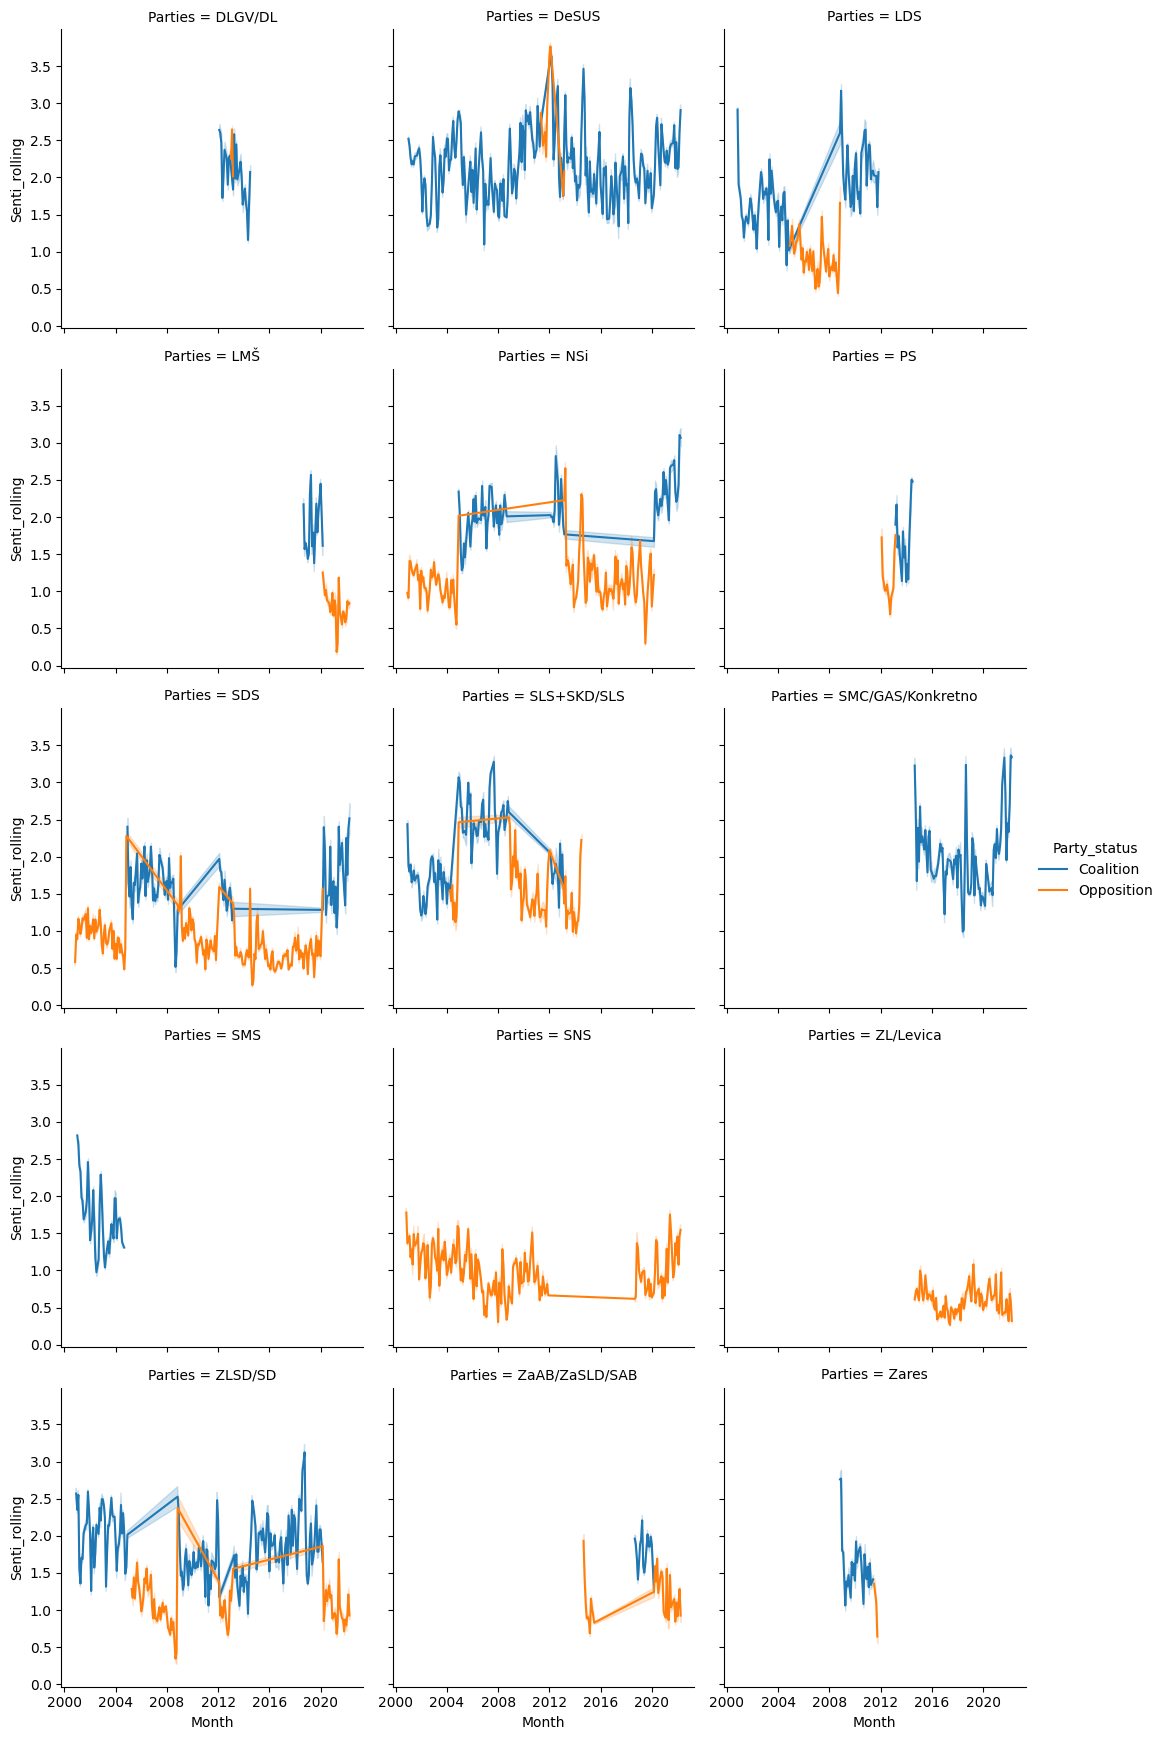

In [4]:
cols = ["IMNS", "-", "NeP", "NP", "Lipa"]
status = df[~df.isin(cols)]
status["Date"] = pd.to_datetime(status["Date"])
status["Year"] = pd.to_datetime(status["Year"])
status["Month"] = status["Date"].dt.to_period("M").dt.to_timestamp()
status = status.sort_values(['Parties', 'Date'])

# Compute rolling mean sentiment over last 30 speeches per party
status['Senti_rolling'] = status.groupby('Parties')['Senti_n'].transform(
    lambda x: x.rolling(30, min_periods=15).mean()
)

sns.relplot(
    data=status, x="Month", y='Senti_rolling', hue='Party_status',
    kind='line', col='Parties', col_wrap=3, height=3.5
)
plt.show()

Party status sentiment shifts:
The plot visualizes relationship between sentiment for individual party per their political status. The rolling sentiment is calculated based on the 30 speeches per party/status subset to smooth the sharp changes in sentiment. 
Trends: 
- The sentiment changes occur when party/group changes their status in the Parliament. The clearest examples of this can be seen for SDS and ZLSD/SD. 
- The sentiment drops when party changes their status from Coalition to Opposition

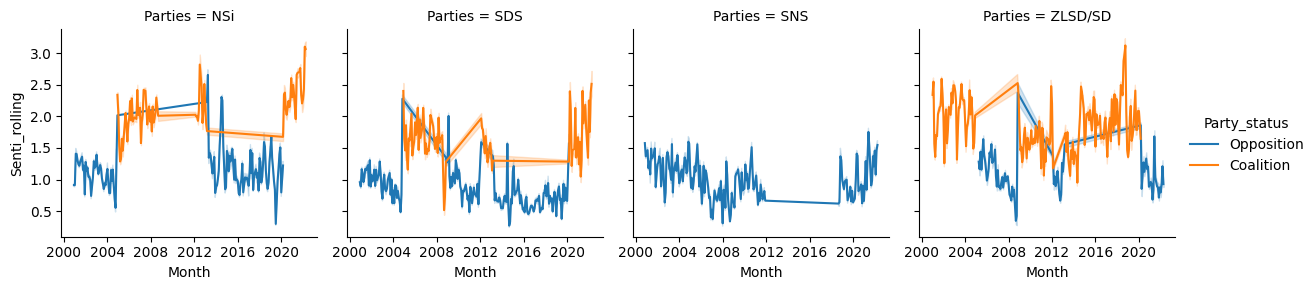

In [5]:
cols = ["SDS", "ZLSD/SD", "NSi", "SNS"]
selection = status[status["Parties"].isin(cols)].copy()


selection['Senti_rolling'] = status.groupby('Parties')['Senti_n'].transform(
    lambda x: x.rolling(30).mean()
)

sns.relplot(
    data=selection, x="Month", y='Senti_rolling', hue='Party_status',
    kind='line', col='Parties', col_wrap=4, height=3
)
plt.show()

Selection of the Parties with the more interesting patterns (Chapter)

In [6]:
# Change rolling sentiment parameter for different visualisations.
# Sample rolling sentiment: rolling(1)
# Full dataset rolling sentiment: rolling(20)
status["Year"] = status["Year"].astype(int)

gov_changes = [
    ("2000-11-30", "6. Gov (Drnovšek)"),
    ("2002-12-19", "7. Gov (Rop)"),
    ("2004-12-03", "8. Gov (Janša)"),
    ("2008-11-21", "9. Gov (Pahor)"), 
    ("2012-02-10", '10. Gov (Janša)'),
    ("2013-03-20", '11. Gov (Bratušek)'), 
    ("2014-09-18", '12. Gov (Cerar)'),
    ("2018-09-13", '13. Gov (Šarec)'),
    ('2020-03-13', '14. Gov (Janša)'),
    
]

term_changes = [
    ("2004-10-21", "Term 4"), 
    ("2008-10-14", "Term 5"),
    ("2011-12-20", "Term 6"),
    ("2014-07-03", "Term 7"),
    ("2018-06-21", "Term 8"),
]
trend_blocs = (
    status.groupby([status["Date"].dt.to_period("M"),'Parties'])['Senti_n']
      .mean().unstack().rolling(20).mean()
)

trend_blocs

Parties,DLGV/DL,DeSUS,LDS,LMŠ,NSi,PS,SDS,SLS+SKD/SLS,SMC/GAS/Konkretno,SMS,SNS,ZL/Levica,ZLSD/SD,ZaAB/ZaSLD/SAB,Zares
Date,,,,,,,,,,,,,,,
2000-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12,NaN,2.377089,NaN,0.776160,2.334891,NaN,1.675075,NaN,2.169331,NaN,1.125013,0.591636,1.042293,1.160790,NaN
2022-01,NaN,2.361318,NaN,0.762347,2.360358,NaN,1.711824,NaN,2.220948,NaN,1.120472,0.573091,1.010647,1.160048,NaN
2022-02,NaN,2.359041,NaN,0.741399,2.352040,NaN,1.662624,NaN,2.279031,NaN,1.116820,0.589933,1.017205,1.130131,NaN


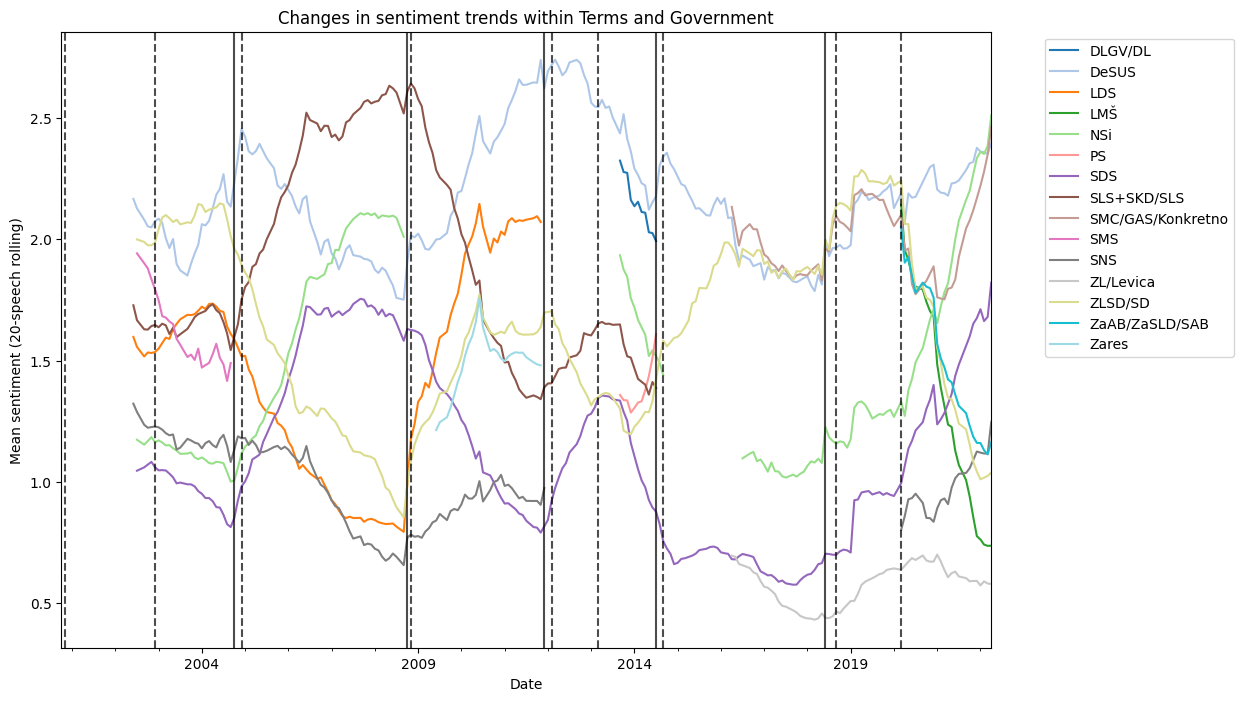

In [7]:
trend_blocs.plot(figsize=(12,8), cmap="tab20")
for date, label in gov_changes:
    plt.axvline(pd.Timestamp(date), color='black', linestyle='--', alpha=0.7)

for date, label in term_changes:
    plt.axvline(pd.Timestamp(date), color='black', linestyle='-', alpha=0.7)
plt.title("Changes in sentiment trends within Terms and Government")
plt.ylabel("Mean sentiment (20-speech rolling)")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

Rolling sentiment - Coalition vs. Opposition
The plot presents the rolling average sentiment calculated for individual party per month to showcase the trends in sentiment changes throughout the period. The vertical lines represent changes in government, and therefore, switches between coalition and opposition parties (or, rather, their status, if it occurs).

2002 - 2004 (Term 4)
- 7th Government - Rop:
    - Higher sentiment/rise in sentiment: ZLSD/SD, DeSUS, SMS (downward trajectory), SLS+SKD/SLS
    - Lower sentiment/drop in sentiment: SNS, NSi, SDS
    - Additional transistion within this Government - SLS moved from coalition to opposition in second half of 2004.

      <relation name="coalition" mutual="#party.LDS.2 #party.ZLSD #party.SLS.2 #party.DeSUS #party.SMS" from="2002-12-19" to="2004-04-19" ana="#GOV.7"/>
      <relation name="opposition" active="#party.SDS.2 #party.NSi #party.SNS" passive="#GOV" from="2002-12-19" to="2004-04-19" ana="#GOV.7"/>
      <relation name="coalition" mutual="#party.LDS.2 #party.ZLSD #party.DeSUS #party.SMS" from="2004-04-20" to="2004-12-02" ana="#GOV.7"/>
      <relation name="opposition" active="#party.SDS.2 #party.NSi #party.SLS.2 #party.SNS" passive="#GOV" from="2004-04-20" to="2004-12-02" ana="#GOV.7"/>

2004 - 2008 (Term 5)
- 8th Government - Janša
  - Higher sentiment/rise in sentiment: SLS, DeSUS, NSi, SDS, 
  - Lower sentiment/drop in sentiment: LDS, ZLSD/SD, SNS
  - NSi only present until the end of Term


   <relation name="coalition" mutual="#party.SDS.2 #party.NSi #party.SLS.2 #party.DeSUS" from="2004-12-03" to="2008-11-20" ana="#GOV.8"/>
      <relation name="opposition" active="#party.LDS.2 #party.SD #party.SNS" passive="#GOV" from="2004-12-03" to="2008-11-20" ana="#GOV.8"/>

2008 (9th Government - Pahor):
- Higher sentiment/rise in sentiment: LDS, DeSUS , ZLSD/SD, Zares
- SLower sentiment/drop in sentiment: SLS+SKD/SLS, SDS, SNS 
- LDS and SNS present only until the end of Term

<relation name="coalition" mutual="#party.SD #party.Zares.1 #party.DeSUS #party.LDS.2" from="2008-11-21" to="2011-05-09" ana="#GOV.9"/>
<relation name="opposition" active="#party.SDS.2 #party.SNS #party.SLS.2" passive="#GOV" from="2008-11-21" to="2011-05-09" ana="#GOV.9"/>

2012 (10th Government - Janša): 
- DeSUS (slightly), ZLSD/SD, - sentiment goes down,
- SLS+SKS/SLS (SLS), SDS - sentiment goes up



2013 (11th Government - Bratušek):
- SDS, SLS, DeSUS - sentiment goes down, 
- ZLSD/SD (SD) sentiment goes slightly down but picks up again in the middle of the Year
- NSi, DLGV/DL, PS (re)join Parliament, sentiment is on the downward trend for NSi and DLGV/DL, PS sentiment on upward trend

2014 (12th Government - Cerar):
- SDS, DeSUS, SMC (new), NSi - sentiment is on a downward trend, 
- SD - sentiment up, 
- Levica, ZaAB elected into Parliament, lower(est) sentiment trend

2018 (13th Government - Šarec):
- Short period, will be further evaluated for closer changes in Sentiment within Term-based trends

2020 (14th Government - Janša):
- LMŠ, ZLSD/SD, SAB, Levica down, 
- SNS, SDS, NSi, DeSUS up



In [8]:
trend_blocs = (
    status.groupby([status["Date"].dt.to_period("M"),'Parties'])['Senti_n']
      .mean().unstack().rolling(10).mean()[['ZLSD/SD', 'SDS']]
)

trend_blocs

Parties,ZLSD/SD,SDS
Date,,
2000-10,NaN,NaN
2000-11,NaN,NaN
2000-12,NaN,NaN
2001-01,NaN,NaN
2001-02,NaN,NaN
...,...,...
2021-12,0.915089,1.632739
2022-01,0.951984,1.752825
2022-02,0.948123,1.772534


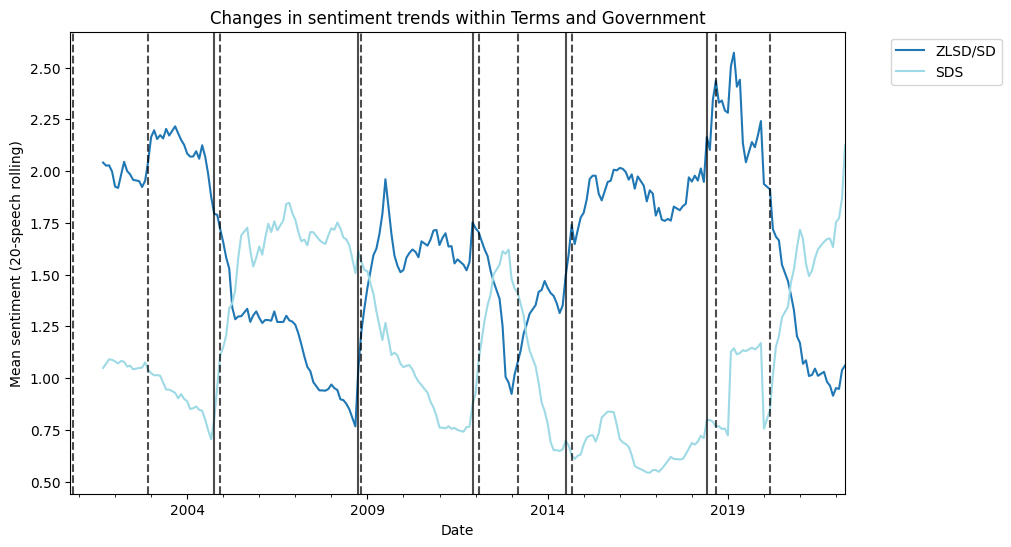

In [9]:
trend_blocs.plot(figsize=(10,6), cmap="tab20")
for date, label in gov_changes:
    plt.axvline(pd.Timestamp(date), color='black', linestyle='--', alpha=0.7)

for date, label in term_changes:
    plt.axvline(pd.Timestamp(date), color='black', linestyle='-', alpha=0.7)
plt.title("Changes in sentiment trends within Terms and Government")
plt.ylabel("Mean sentiment (20-speech rolling)")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

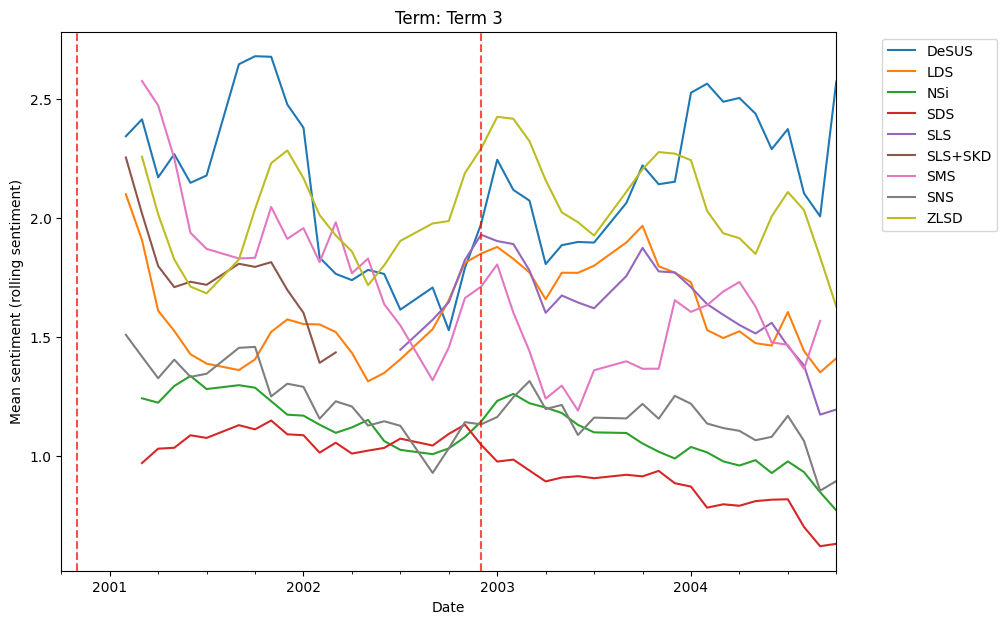

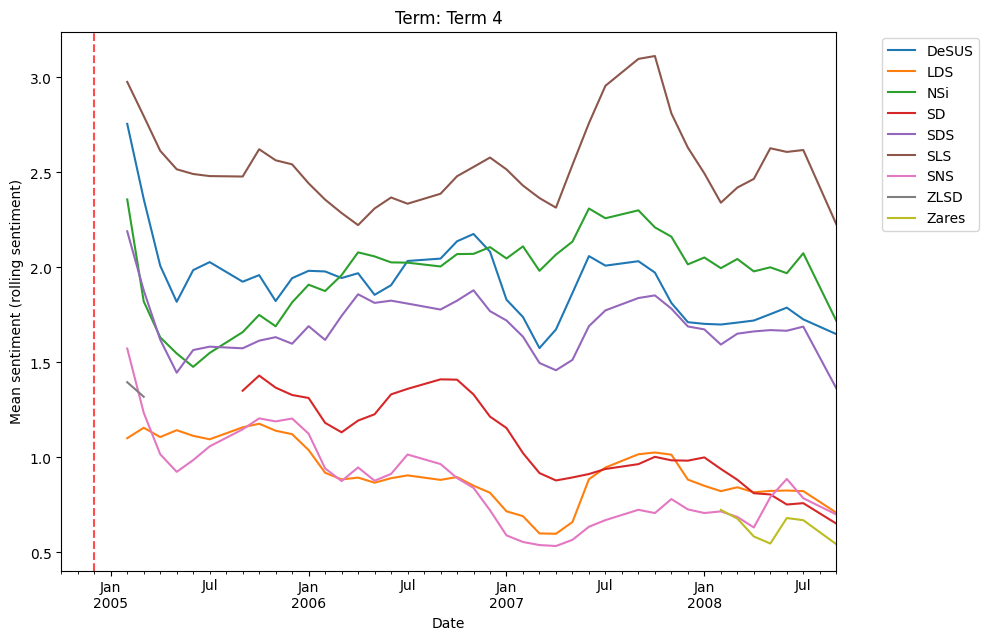

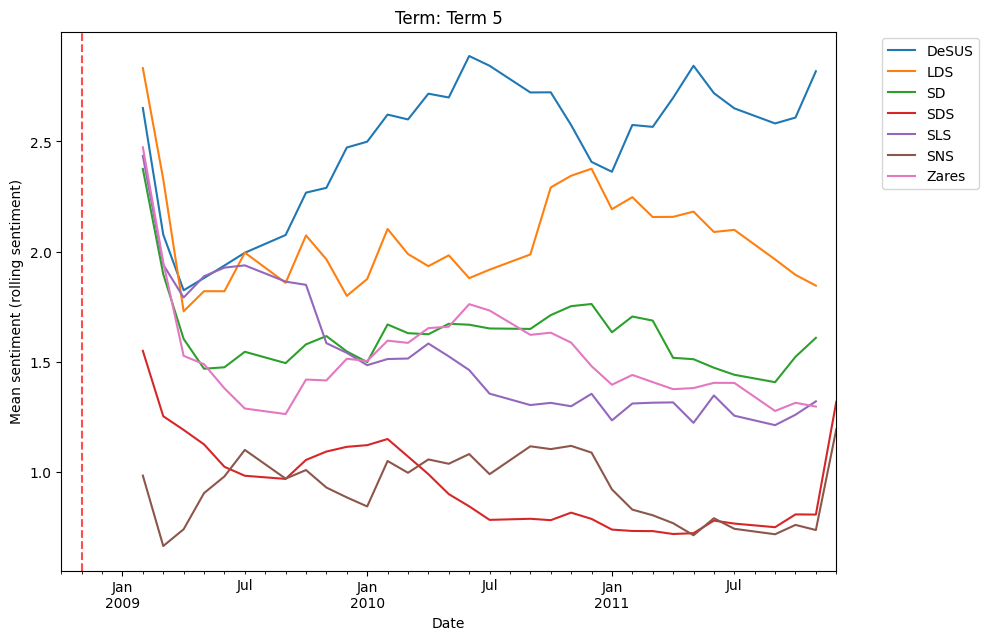

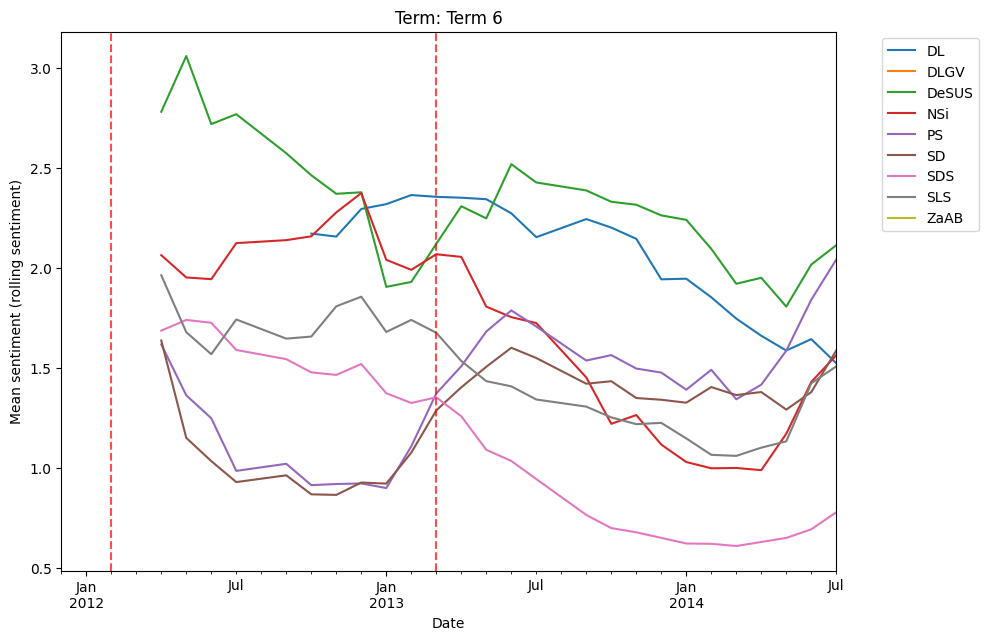

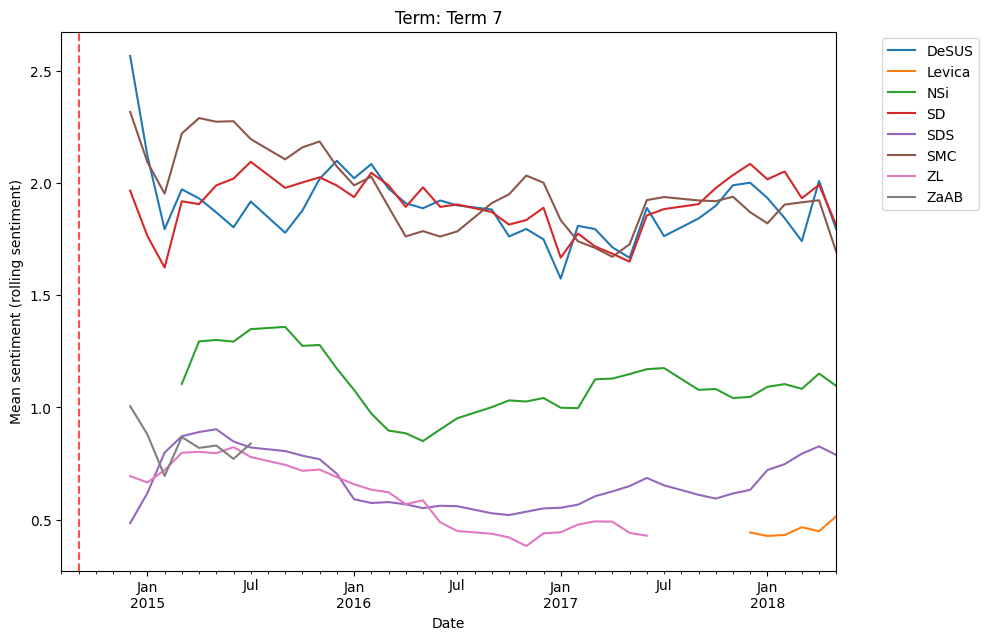

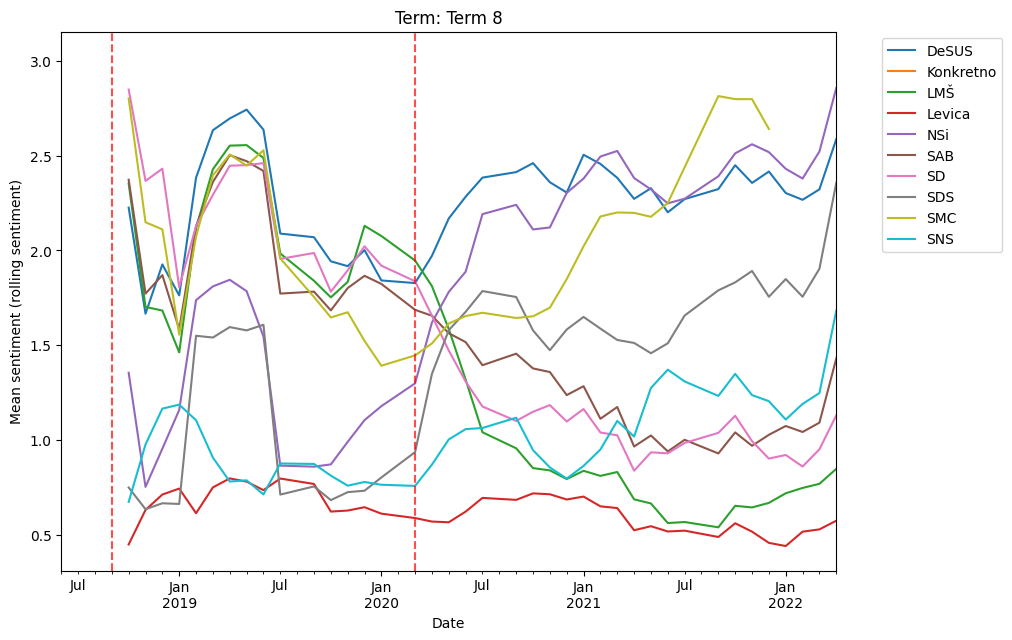

In [10]:
# Individual Term plots (with all government changes in each Term)
# Sample rolling sentiment: rolling(1)
# Full dataset rolling sentiment: rolling(5)

for term, sub in status.groupby('Term'):
    trend = sub.groupby([status["Date"].dt.to_period("M"),'Speaker_party'])['Senti_n'].mean().unstack().rolling(5).mean()
    trend.plot(figsize=(10,7), title=f"Term: {term}")
    plt.ylabel("Mean sentiment (rolling sentiment)")
    for date, label in gov_changes:
        if sub['Date'].min() <= pd.Timestamp(date) <= sub['Date'].max():
            plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
        plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.show()

Individual Term plot - Rolling sentiment by Party (Month)

Term 3:
- Due to rolling sentiment direct changes in Gov 6 are not possible
- Gov 7 changes (2002-12-19, 7. Gov (Rop)):
    - ZLSD, DeSUS, SMS, LDS, SLS: sentiment rising (from opposition to coalition)
    - SDS, NSi, SNS (slightly): sentiment dropping (going from opposition to coalition)

Term 4:
- 2004-12-03, 8. Gov (Janša), Clearer division in senitment: 
    - SLS, DeSUS, NSi, SDS: sentiment rising (going from opposition to coalition)
    - SD, LDS, SNS: sentiment dropping (lower in the entire term): going from coalition to opposition

Term 5: (2008-11-21, 9. Gov (Pahor): Not so clear distinctions between the party sentiment
- Higher in sentiment: DeSUS, LDS, SD, Zares (coalition)
- Lower in sentiment: SDS, SNS, SLS (drop later in the Gov term), (opposition)

Term 6: (2012-02-10, 10. Gov (Janša):
- DeSUS, NSi, SLS, SDS -> Higher in sentiment (coalition)
- PS, SD -> Lower in sentiment, (opposition)

- (2013-03-20", '11. Gov (Bratušek)'):
    - PS, SD -> Sentiment rising, going from opposition to coaliton
    - SDS, DeSUS, NSi, SLS -> sentiment dropping, coalition to opposition 

Term 7:
-  (2014-09-18", '12. Gov (Cerar)'),
    - Clear distinction in sentiment between coal and oppo parties:
    - SMC, SD, DeSUS - higher in sentiment (in coalition)
    - SDS, NSi, ZL, ZaAB - lower in sentiment (in opposition)

Term 8
-  ("2018-09-13", '13. Gov (Šarec)')
    - LMŠ, SMC, SD, SAB, DeSUS - Higher in sentiment (coalition)
        - Levica, NSi, SDS, SNS - dropping in sentiment (opposition)
-   '2020-03-13', '14. Gov (Janša)',
    - SDS, NSi, SMC, DeSUS - rising in sentiment (coalition)
    - SAB, Levica, SD, LMŠ, SNS (though Levica is really low in sentiment at any given position)




In [11]:
df["Month"] = df["Date"].str.split("-").str[:2].str.join("-")

activity = df.groupby(['Term','Parties']).agg( #Can also be checked by aggregated parties - "Parties"
    Start_date=('Date', 'min'),
    End_date=('Date', 'max'),
    Speech_count=('Date', 'size'),
    Avg_sentiment=('Senti_n','mean')

).reset_index()
activity = activity[~activity['Parties'].isin(["-"])] #"NP", NeP
activity["Parties"].sort_values(ascending=True)

activity.head()

import plotly.express as px
fig = px.timeline(
        activity,
        x_start="Start_date",
        x_end="End_date",
        y="Parties",
        color="Avg_sentiment",
        title=f"Sentiment Shifts across Terms",
        labels={"Avg_sentiment": "Sentiment (mean)"}
    )
fig.update_yaxes(autorange="reversed") 
fig.update_layout(
        height=600,  
        width=950,
        yaxis_title="Parties",
        xaxis_title="")
fig.show()

In [12]:
year_activity = df.groupby(['Term', 'Year', 'Speaker_party']).agg( #Can also be checked by aggregated parties - "Parties"
    Start_date=('Date', 'min'),
    End_date=('Date', 'max'),
    Speech_count=('Date', 'size'),
    Avg_sentiment=('Senti_n','mean')

).reset_index()
year_activity = year_activity[~year_activity['Speaker_party'].isin(["-"])] #"NP", NeP
year_activity["Speaker_party"].sort_values(ascending=True)

year_activity.head()

for term, df_term in year_activity.groupby("Term"):
    fig = px.timeline(
        df_term,
        x_start="Start_date",
        x_end="End_date",
        y="Speaker_party",
        color="Avg_sentiment",
        title=f"Sentiment Shifts across Years — {term}",
        labels={"Avg_sentiment": "Sentiment (mean)"}
    )
    fig.update_yaxes(autorange="reversed") 
    fig.update_layout(
        height=600,  
        width=950,
        yaxis_title="Parties",
        xaxis_title="")
    fig.show()

In [13]:
gov_changes = [(pd.Timestamp(d), name) for d, name in gov_changes]
gov_changes

[(Timestamp('2000-11-30 00:00:00'), '6. Gov (Drnovšek)'),
 (Timestamp('2002-12-19 00:00:00'), '7. Gov (Rop)'),
 (Timestamp('2004-12-03 00:00:00'), '8. Gov (Janša)'),
 (Timestamp('2008-11-21 00:00:00'), '9. Gov (Pahor)'),
 (Timestamp('2012-02-10 00:00:00'), '10. Gov (Janša)'),
 (Timestamp('2013-03-20 00:00:00'), '11. Gov (Bratušek)'),
 (Timestamp('2014-09-18 00:00:00'), '12. Gov (Cerar)'),
 (Timestamp('2018-09-13 00:00:00'), '13. Gov (Šarec)'),
 (Timestamp('2020-03-13 00:00:00'), '14. Gov (Janša)')]

In [14]:
from pandas.api.types import CategoricalDtype

df["Date"] = pd.to_datetime(df["Date"])


sentiment_shifts = []
for i, (change_date, gov_name) in enumerate(gov_changes):
    prev_date = gov_changes[i-1][0] if i > 0 else df['Date'].min()
    next_date = gov_changes[i+1][0] if i+1 < len(gov_changes) else df['Date'].max()

    before = df[(df['Date'] >= prev_date) & (df['Date'] < change_date)]
    after  = df[(df['Date'] >= change_date) & (df['Date'] < next_date)]
    

    before_mean = before.groupby('Speaker_party')['Senti_n'].mean().rename('Sent_Before')
    after_mean  = after.groupby('Speaker_party')['Senti_n'].mean().rename('Sent_After')

    merged = pd.concat([before_mean, after_mean], axis=1)
    merged['Start_date_before'] = prev_date
    merged['End_date_before'] = change_date
    merged['Gov_change'] = gov_name
    merged['Start_date_after'] = change_date
    merged['End_date_after'] = next_date
    merged['Change'] = merged['Sent_After'] - merged['Sent_Before']
    sentiment_shifts.append(merged.reset_index())

sentiment_shift_df = pd.concat(sentiment_shifts, ignore_index=True)
sentiment_shift_df

gov_order = CategoricalDtype(['6. Gov (Drnovšek)', '7. Gov (Rop)', '8. Gov (Janša)', '9. Gov (Pahor)', '10. Gov (Janša)', '11. Gov (Bratušek)', '12. Gov (Cerar)', '13. Gov (Šarec)', '14. Gov (Janša)'], ordered=True)
sentiment_shift_df['Gov_change'] = sentiment_shift_df['Gov_change'].astype(gov_order)

order = ["Speaker_party", "Start_date_before", "End_date_before", "Sent_Before", "Gov_change", "Start_date_after", "End_date_after", "Sent_After", "Change"]
sentiment_shift_df = sentiment_shift_df[order]
sentiment_shift_df


,Speaker_party,Start_date_before,End_date_before,Sent_Before,Gov_change,Start_date_after,End_date_after,Sent_After,Change
0,DeSUS,2000-10-27,2000-11-30,3.203333,6. Gov (Drnovšek),2000-11-30,2002-12-19,2.056689,-1.146645
1,IMNS,2000-10-27,2000-11-30,2.470000,6. Gov (Drnovšek),2000-11-30,2002-12-19,1.511117,-0.958883
2,LDS,2000-10-27,2000-11-30,2.901000,6. Gov (Drnovšek),2000-11-30,2002-12-19,1.484091,-1.416909
3,SLS+SKD,2000-10-27,2000-11-30,2.702222,6. Gov (Drnovšek),2000-11-30,2002-12-19,1.592925,-1.109297
4,SMS,2000-10-27,2000-11-30,2.552000,6. Gov (Drnovšek),2000-11-30,2002-12-19,1.845142,-0.706858
...,...,...,...,...,...,...,...,...,...
118,SMC,2018-09-13,2020-03-13,1.638247,14. Gov (Janša),2020-03-13,2022-04-06,2.080694,0.442447
119,SNS,2018-09-13,2020-03-13,0.907553,14. Gov (Janša),2020-03-13,2022-04-06,1.167805,0.260252
120,Konkretno,2018-09-13,2020-03-13,NaN,14. Gov (Janša),2020-03-13,2022-04-06,2.817143,NaN
121,NP,2018-09-13,2020-03-13,NaN,14. Gov (Janša),2020-03-13,2022-04-06,1.197165,NaN


In [15]:
#Sanity check
sentiment_shift_df[sentiment_shift_df["Speaker_party"] == "SMC"]

,Speaker_party,Start_date_before,End_date_before,Sent_Before,Gov_change,Start_date_after,End_date_after,Sent_After,Change
76,SMC,2012-02-10,2013-03-20,NaN,11. Gov (Bratušek),2013-03-20,2014-09-18,3.268810,NaN
89,SMC,2013-03-20,2014-09-18,3.268810,12. Gov (Cerar),2014-09-18,2018-09-13,1.967163,-1.301647
106,SMC,2014-09-18,2018-09-13,1.967163,13. Gov (Šarec),2018-09-13,2020-03-13,1.638247,-0.328915
118,SMC,2018-09-13,2020-03-13,1.638247,14. Gov (Janša),2020-03-13,2022-04-06,2.080694,0.442447


In [16]:
sentiment_shift_df.pivot_table(
    index='Speaker_party', columns='Gov_change', values='Change', observed=True
).round(2)

Gov_change,6. Gov (Drnovšek),7. Gov (Rop),8. Gov (Janša),9. Gov (Pahor),10. Gov (Janša),11. Gov (Bratušek),12. Gov (Cerar),13. Gov (Šarec),14. Gov (Janša)
Speaker_party,,,,,,,,,
DL,NaN,NaN,NaN,NaN,NaN,-0.35,NaN,NaN,NaN
DLGV,NaN,NaN,NaN,NaN,-0.27,NaN,NaN,NaN,NaN
DeSUS,-1.15,0.24,-0.43,0.60,-0.18,-0.06,-0.31,0.03,0.46
IMNS,-0.96,-0.06,0.67,-0.18,0.46,-0.40,0.41,1.23,0.07
LDS,-1.42,0.09,-0.65,1.09,NaN,NaN,NaN,NaN,NaN
LMŠ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.35,-1.04
Levica,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.24,-0.11
NP,NaN,NaN,NaN,0.68,NaN,NaN,-0.13,NaN,NaN
NSi,NaN,-0.16,0.94,0.06,0.19,-0.89,-0.23,0.04,1.31


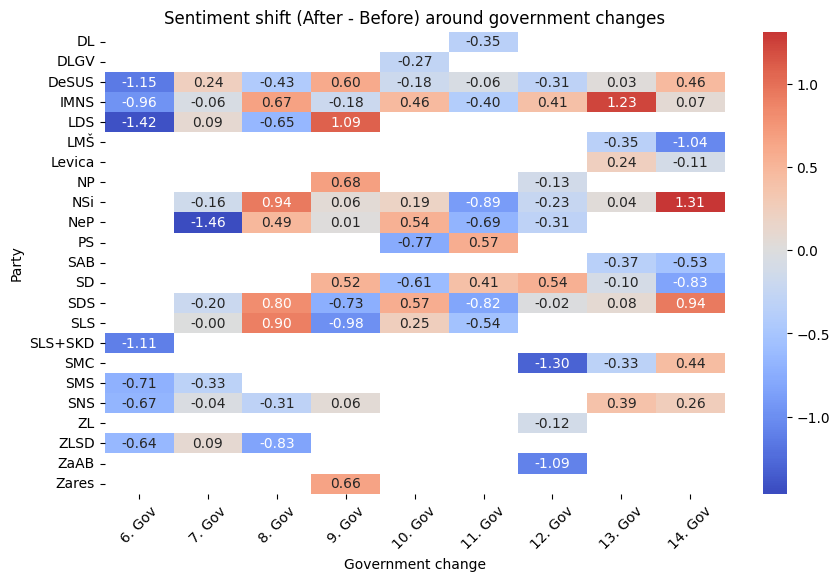

In [17]:
import seaborn as sns
plt.figure(figsize=(10,6))



ax = sns.heatmap(
    sentiment_shift_df.pivot_table(
        index='Speaker_party', columns='Gov_change', observed=True, values='Change',
    ),
    cmap='coolwarm', center=0, annot=True, fmt=".2f"
)

ax.set_xticklabels([label.get_text().split(" (")[0] for label in ax.get_xticklabels()])
plt.title('Sentiment shift (After - Before) around government changes')
plt.ylabel('Party')
plt.xlabel('Government change')
plt.xticks(rotation=45)
plt.show()

Sentiment shift changes (heatmap)
Comparing changes in sentiment between parties and changes in government.
- The largest change recorded is the NSi shift from the 13th to the 14th government (Šarec to Janša), with a positive increase in sentiment (1.31), while the greatest decrease in sentiment is for LDS in the 6th government with -1.42, followed by SMC in the transition from government 11 to government 12 (Bratušek to Cerar, -1.30).
- DeSUS remains relatively stable in sentiment throughout the government changes, with only slight variations.

In [18]:
gov_periods = pd.DataFrame({
    "Gov": ["Gov5", "Gov6", "Gov7", "Gov8", "Gov9", "Gov10", "Gov11", "Gov12", "Gov13", "Gov14"],
    "Start_date": ["2000-06-07", "2000-11-30", "2002-12-19", "2004-12-03", "2008-11-21", "2012-02-10", "2013-03-20", "2014-09-18", "2018-09-13", "2020-03-13"],
    "End_date": ["2000-11-30", "2002-12-19", "2004-12-03", "2008-11-21", "2012-02-10", "2013-03-20", "2014-09-18", "2018-09-13", "2020-03-13", "2022-06-01"]
})

gov_periods["Start_date"] = pd.to_datetime(gov_periods["Start_date"])
gov_periods["End_date"] = pd.to_datetime(gov_periods["End_date"])
gov_periods

,Gov,Start_date,End_date
0,Gov5,2000-06-07,2000-11-30
1,Gov6,2000-11-30,2002-12-19
2,Gov7,2002-12-19,2004-12-03
3,Gov8,2004-12-03,2008-11-21
4,Gov9,2008-11-21,2012-02-10
5,Gov10,2012-02-10,2013-03-20
6,Gov11,2013-03-20,2014-09-18
7,Gov12,2014-09-18,2018-09-13
8,Gov13,2018-09-13,2020-03-13
9,Gov14,2020-03-13,2022-06-01


In [19]:
df["Date"] = pd.to_datetime(df['Date'])

gov = df = pd.merge_asof(
    df.sort_values('Date'),
    gov_periods.sort_values('Start_date'),
    left_on='Date',
    right_on='Start_date',
    direction='backward'
)

gov.head()
gov.shape

(130633, 34)

In [20]:
#Identify wrongly annotated speeches/session
gov_check = gov.loc[
    (gov["Term"] == "Term 7") & 
    (gov["Gov"] == "Gov13"),
]
gov_check

,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Parties,Year,party_id,lrgen,galtan,Seat,Month,Gov,Start_date,End_date


In [21]:
check = gov["Gov"].notna()
len(check) #--> Confirm that no Gov is missing/not assigned

130633

In [22]:
avg_sentiment = (
    gov.groupby(['Term','Gov', 'Speaker_party'])
      .agg(Avg_sentiment=('Senti_n', 'mean'))
      .reset_index()
)
avg_sentiment = avg_sentiment.merge(
    gov_periods[['Gov', 'Start_date', 'End_date']],
    on='Gov',
    how='left'
)
avg_sentiment
gov_order = CategoricalDtype(["Gov5", "Gov6", "Gov7", "Gov8", "Gov9", "Gov10", "Gov11", "Gov12", "Gov13", "Gov14"], ordered=True)
avg_sentiment["Gov"] = avg_sentiment["Gov"].astype(gov_order)


In [23]:
avg_sentiment

,Term,Gov,Speaker_party,Avg_sentiment,Start_date,End_date
0,Term 3,Gov5,DeSUS,3.203333,2000-06-07,2000-11-30
1,Term 3,Gov5,IMNS,2.470000,2000-06-07,2000-11-30
2,Term 3,Gov5,LDS,2.901000,2000-06-07,2000-11-30
3,Term 3,Gov5,SLS+SKD,2.702222,2000-06-07,2000-11-30
4,Term 3,Gov5,SMS,2.552000,2000-06-07,2000-11-30
...,...,...,...,...,...,...
143,Term 8,Gov14,SAB,1.206966,2020-03-13,2022-06-01
144,Term 8,Gov14,SD,1.021557,2020-03-13,2022-06-01
145,Term 8,Gov14,SDS,1.703361,2020-03-13,2022-06-01
146,Term 8,Gov14,SMC,2.080694,2020-03-13,2022-06-01


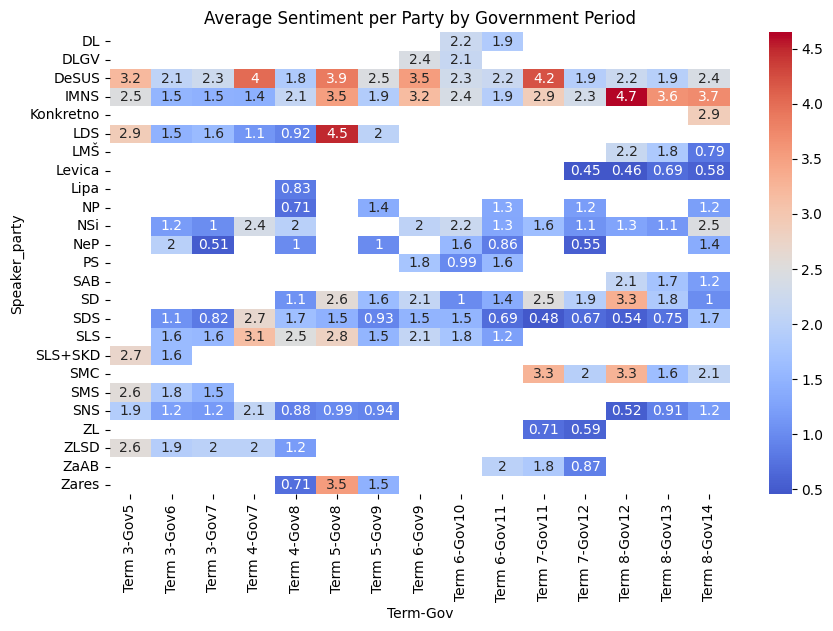

In [24]:
pivot = avg_sentiment.pivot(index="Speaker_party", columns=["Term", "Gov"], values="Avg_sentiment")
pivot = pivot.sort_index(axis=1)


plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", center=2.5)
plt.title("Average Sentiment per Party by Government Period")
plt.xticks(rotation=90)
plt.show()

Though the changes in scores might not be seen as too drastic, the most distinct changes in sentiment average (e.g. LDS in Gov5-6, or NSI in Gov13-14) still denote changes in sentiment labels (e.g. jump from 1.1 which is still quite Negative to 2.5, which can be intepreted as Neutral), effectively changing an entire 3-class sentiment label (and several labels in 6-class). Remaining changes are not too drastic, which is understandable given the generally low sentiment (mean sentiment score of the entire dataset under analysis is 1.29, while the median is 0.6). 
Additionally, when plotting sentiment trends for individual parties by party status, party orientation, etc., the highest average sentiment barely reached around 2.5/3.

In [25]:
fig = px.timeline(
    avg_sentiment,
    x_start="Start_date",
    x_end="End_date",
    y="Speaker_party",
    color="Avg_sentiment",
    #text="Gov",
    title="Average Sentiment per Party across Government Periods"
)

fig.update_yaxes(autorange="reversed")
fig.update_layout(
        height=700,  
        width=1050)
fig.show()

## Political orientation sentiment shifts

In [26]:
df.head()


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Parties,Year,party_id,lrgen,galtan,Seat,Month,Gov,Start_date,End_date
0,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u9,"V imenu skupine poslancev, ki so bili izvoljen...",2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,LDS,...,LDS,2000,NaN,NaN,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30
1,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u1,[[...]] [[Aplavz.]] [[... ...]] [[Himna.]] [[....,2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,SLS+SKD,...,SLS+SKD/SLS,2000,NaN,NaN,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30
2,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u13,Glede na predhodno obrazložitev naj dodam še t...,2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,LDS,...,LDS,2000,NaN,NaN,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30
3,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u15,"Spoštovani dr. Bernik, kolegice in kolegi! Kot...",2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,SLS+SKD,...,SLS+SKD/SLS,2000,NaN,NaN,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30
4,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u18,"Spoštovani gospod predsedujoči, spoštovane pos...",2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,DeSUS,...,DeSUS,2000,NaN,NaN,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30


In [27]:
check = df[["Year", "Speaker_party", "Parties", "lrgen", "galtan"]].drop_duplicates().sort_values(by="Year").reset_index(drop=True)

#check.to_csv("LRGEN-GALTAN_check.csv") #Sanity check of the initial lrgen/galtan values before interpolation procedure
check

,Year,Speaker_party,Parties,lrgen,galtan
0,2000,LDS,LDS,NaN,NaN
1,2000,SLS+SKD,SLS+SKD/SLS,NaN,NaN
2,2000,DeSUS,DeSUS,NaN,NaN
3,2000,SNS,SNS,NaN,NaN
4,2000,ZLSD,ZLSD/SD,NaN,NaN
...,...,...,...,...,...
231,2022,SD,ZLSD/SD,NaN,NaN
232,2022,Levica,ZL/Levica,NaN,NaN
233,2022,Konkretno,SMC/GAS/Konkretno,NaN,NaN
234,2022,SNS,SNS,NaN,NaN


In [28]:
party_interp = (df.groupby(["Speaker_party", "Year"], as_index=False)[["lrgen", "galtan"]].mean().sort_values(["Speaker_party", "Year"]))
party_interp.head()

,Speaker_party,Year,lrgen,galtan
0,DL,2012,NaN,NaN
1,DL,2013,NaN,NaN
2,DL,2014,NaN,NaN
3,DLGV,2011,NaN,NaN
4,DLGV,2012,NaN,NaN


### Interpolating the CHES values for sentiment switch trends
Given the relatively scares points from the CHES dataset, we decided to interpolate the values for individual years. As we do not want to predic the values for years at both ends of the spectrum (e.g. 2000-2002; 2020-2022), we limit the interpolation method with "both" parameter (values on both ends assume the value of the last Year in CHES dataset (2002 and 2019 respectively))

In [29]:
party_interp[["lrgen", "galtan"]] = (party_interp.groupby("Speaker_party")[["lrgen", "galtan"]].apply(lambda x: x.interpolate(limit_direction="both")).reset_index(drop=True))
party_interp["lrgen"] = party_interp["lrgen"].apply(lambda x: f"{x:.2f}")
party_interp["galtan"] = party_interp["galtan"].apply(lambda x: f"{x:.2f}")

#party_interp.to_csv("LRGEN-GALTAN-sanity-check.csv") #Manual check if interpolation makes sense

In [30]:
df = df.drop(columns=["lrgen", "galtan"]).merge(party_interp, on=["Speaker_party", "Year"], how="left")
df.head()
#df.to_csv("../Sample/Datasets/Sample_interpolated_values.tsv", sep="\t",  encoding='utf-8', index=False) #--> Save full dataset
#df.to_csv("../Results/Datasets/ParlaMint_CHES_interpolated_values.tsv", sep="\t",  encoding='utf-8', index=False) --> Save full dataset


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Parties,Year,party_id,Seat,Month,Gov,Start_date,End_date,lrgen,galtan
0,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u9,"V imenu skupine poslancev, ki so bili izvoljen...",2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,LDS,...,LDS,2000,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30,4.20,3.00
1,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u1,[[...]] [[Aplavz.]] [[... ...]] [[Himna.]] [[....,2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,SLS+SKD,...,SLS+SKD/SLS,2000,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30,6.80,7.20
2,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u13,Glede na predhodno obrazložitev naj dodam še t...,2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,LDS,...,LDS,2000,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30,4.20,3.00
3,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u15,"Spoštovani dr. Bernik, kolegice in kolegi! Kot...",2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,SLS+SKD,...,SLS+SKD/SLS,2000,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30,6.80,7.20
4,ParlaMint-SI_2000-10-27-SDZ3-Redna-01.u18,"Spoštovani gospod predsedujoči, spoštovane pos...",2000-10-27,Term 3,Redna,Reference,Regular,MP,notMinister,DeSUS,...,DeSUS,2000,NaN,NaN,2000-10,Gov5,2000-06-07,2000-11-30,3.40,5.80


### Relation between LRGEN, GALTAN and sentiment 

In [31]:
df["lrgen"] = pd.to_numeric(df["lrgen"], errors="coerce")
df["galtan"] = pd.to_numeric(df["galtan"], errors="coerce")

df["Senti_n"] = pd.to_numeric(df["Senti_n"], errors="coerce")
df["Year"] = df["Year"].astype(int)

sent_lrgen = df.groupby(["Parties", "Party_status", "Year"]).agg(
    sentiment = ("Senti_n", "mean"),
    lrgen = ("lrgen", "mean"),
    galtan=("galtan", "mean"),
).reset_index()

#cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV", "DL", "Konkretno"] #Speaker_party
cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV/DL", "Konkretno"] #Parties

sent_lrgen = sent_lrgen[~sent_lrgen.isin(cols)]
sent_lrgen.head(10)
sent_lrgen.shape

(271, 6)

In [32]:
sent_lrgen = sent_lrgen.melt(
    id_vars=["Parties", "Party_status", "Year"],
    value_vars=["sentiment", "lrgen", "galtan"],
    var_name="Metric",
    value_name="Value"
)
sent_lrgen

,Parties,Party_status,Year,Metric,Value
0,NaN,NaN,2011,sentiment,2.893750
1,NaN,NaN,2012,sentiment,2.188125
2,NaN,Coalition,2012,sentiment,2.220394
3,NaN,Coalition,2013,sentiment,2.057623
4,NaN,Coalition,2014,sentiment,1.610854
...,...,...,...,...,...
808,Zares,Coalition,2008,galtan,1.800000
809,Zares,Coalition,2009,galtan,1.800000
810,Zares,Coalition,2010,galtan,1.800000
811,Zares,Coalition,2011,galtan,1.800000


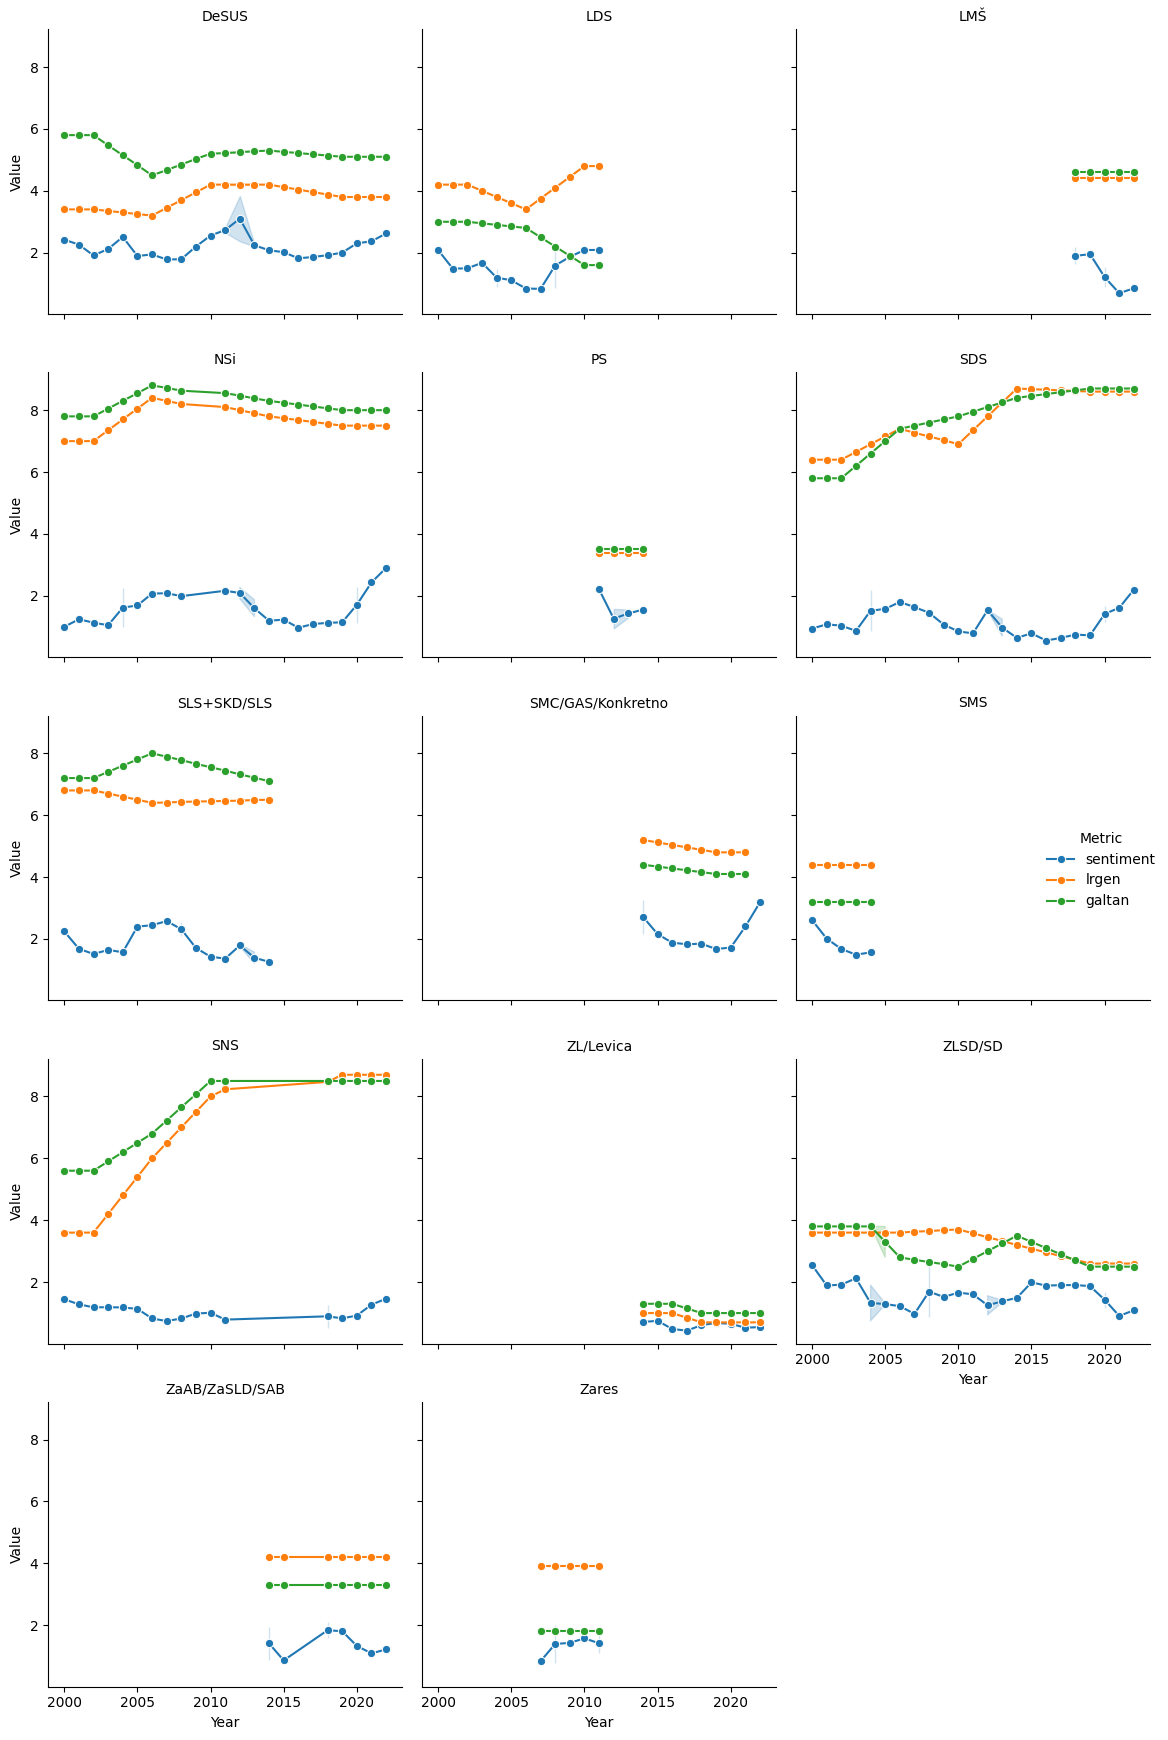

In [33]:
g = sns.FacetGrid(sent_lrgen, col="Parties", col_wrap=3, height=3.5, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="Year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

Relationship between sentiment and LREGN:
The plot visualises relationship between averaged sentiment and LRGEN scores per Year per Party. The lines (or triangles) in sentiment trends denote changes in the party status (e.g. moving from opposition to coalition, or vice versa).The most distinct trend in most of the party trends is the distinct difference between sentiment and lrgen value, where (with exception of ZL/Levica), the sentiment is considerabley lower (and does not fluctuate distinctly with direction of the lrgen change). The same relationship, which can be observed for LRGEN holds true also for GALTAN/sentiment trends, where (with exception of ZL/Levica), the trends are distinctly different in lrgen/sentiment scores. In addition to Levica, LDS does have some more distinct sentiment trends, where the sentiment rises when their galtan score lowers.

In [34]:
select = ["SNS", "ZL/Levica", "SDS", "NSi"]
lrgal_select = sent_lrgen[sent_lrgen["Parties"].isin(select)].reset_index(drop=True)
lrgal_select



,Parties,Party_status,Year,Metric,Value
0,NSi,NaN,2011,sentiment,2.165000
1,NSi,NaN,2012,sentiment,1.908750
2,NSi,Coalition,2004,sentiment,2.238846
3,NSi,Coalition,2005,sentiment,1.690827
4,NSi,Coalition,2006,sentiment,2.071951
...,...,...,...,...,...
238,ZL/Levica,Opposition,2018,galtan,1.000000
239,ZL/Levica,Opposition,2019,galtan,1.000000
240,ZL/Levica,Opposition,2020,galtan,1.000000
241,ZL/Levica,Opposition,2021,galtan,1.000000


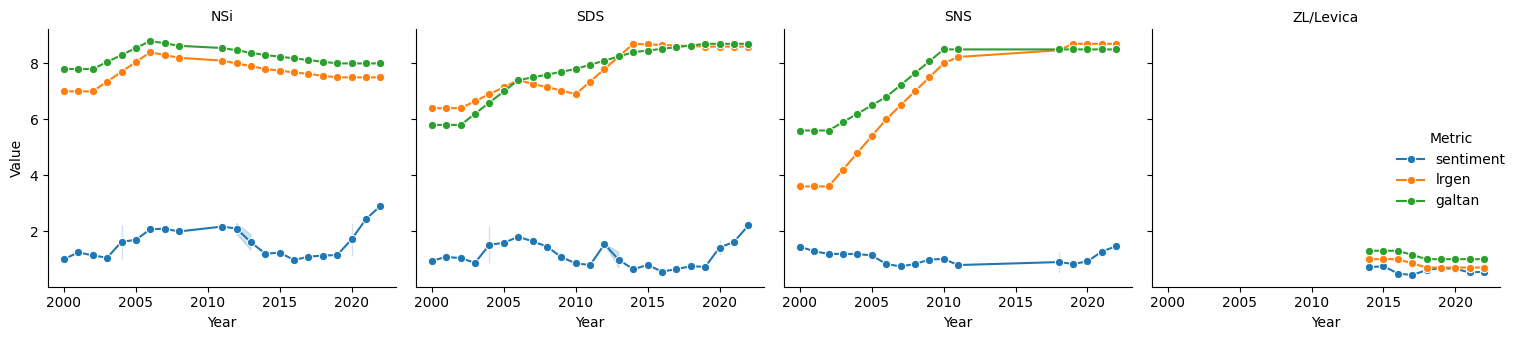

In [35]:
g = sns.FacetGrid(lrgal_select, col="Parties", col_wrap=4, height=3.5, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="Year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### Relationship between galtan and sentiment
Visualise and inspect lrgen and galtan individually - replace "galtan" with "lrgen" to visualise other trend.

In [36]:
df["galtan"] = pd.to_numeric(df["galtan"], errors="coerce")

sent_galtan = df.groupby(["Parties", "Party_status", "Year"]).agg(
    sentiment = ("Senti_n", "mean"),
    galtan = ("galtan", "mean"),
).reset_index()

sent_galtan = sent_galtan[~sent_galtan.isin(cols)]

In [37]:
sent_galtan = sent_galtan.melt(
    id_vars=["Parties", "Party_status", "Year"],
    value_vars=["sentiment", "galtan"],
    var_name="Metric",
    value_name="Value"
)

sent_galtan

,Parties,Party_status,Year,Metric,Value
0,NaN,NaN,2011,sentiment,2.893750
1,NaN,NaN,2012,sentiment,2.188125
2,NaN,Coalition,2012,sentiment,2.220394
3,NaN,Coalition,2013,sentiment,2.057623
4,NaN,Coalition,2014,sentiment,1.610854
...,...,...,...,...,...
537,Zares,Coalition,2008,galtan,1.800000
538,Zares,Coalition,2009,galtan,1.800000
539,Zares,Coalition,2010,galtan,1.800000
540,Zares,Coalition,2011,galtan,1.800000


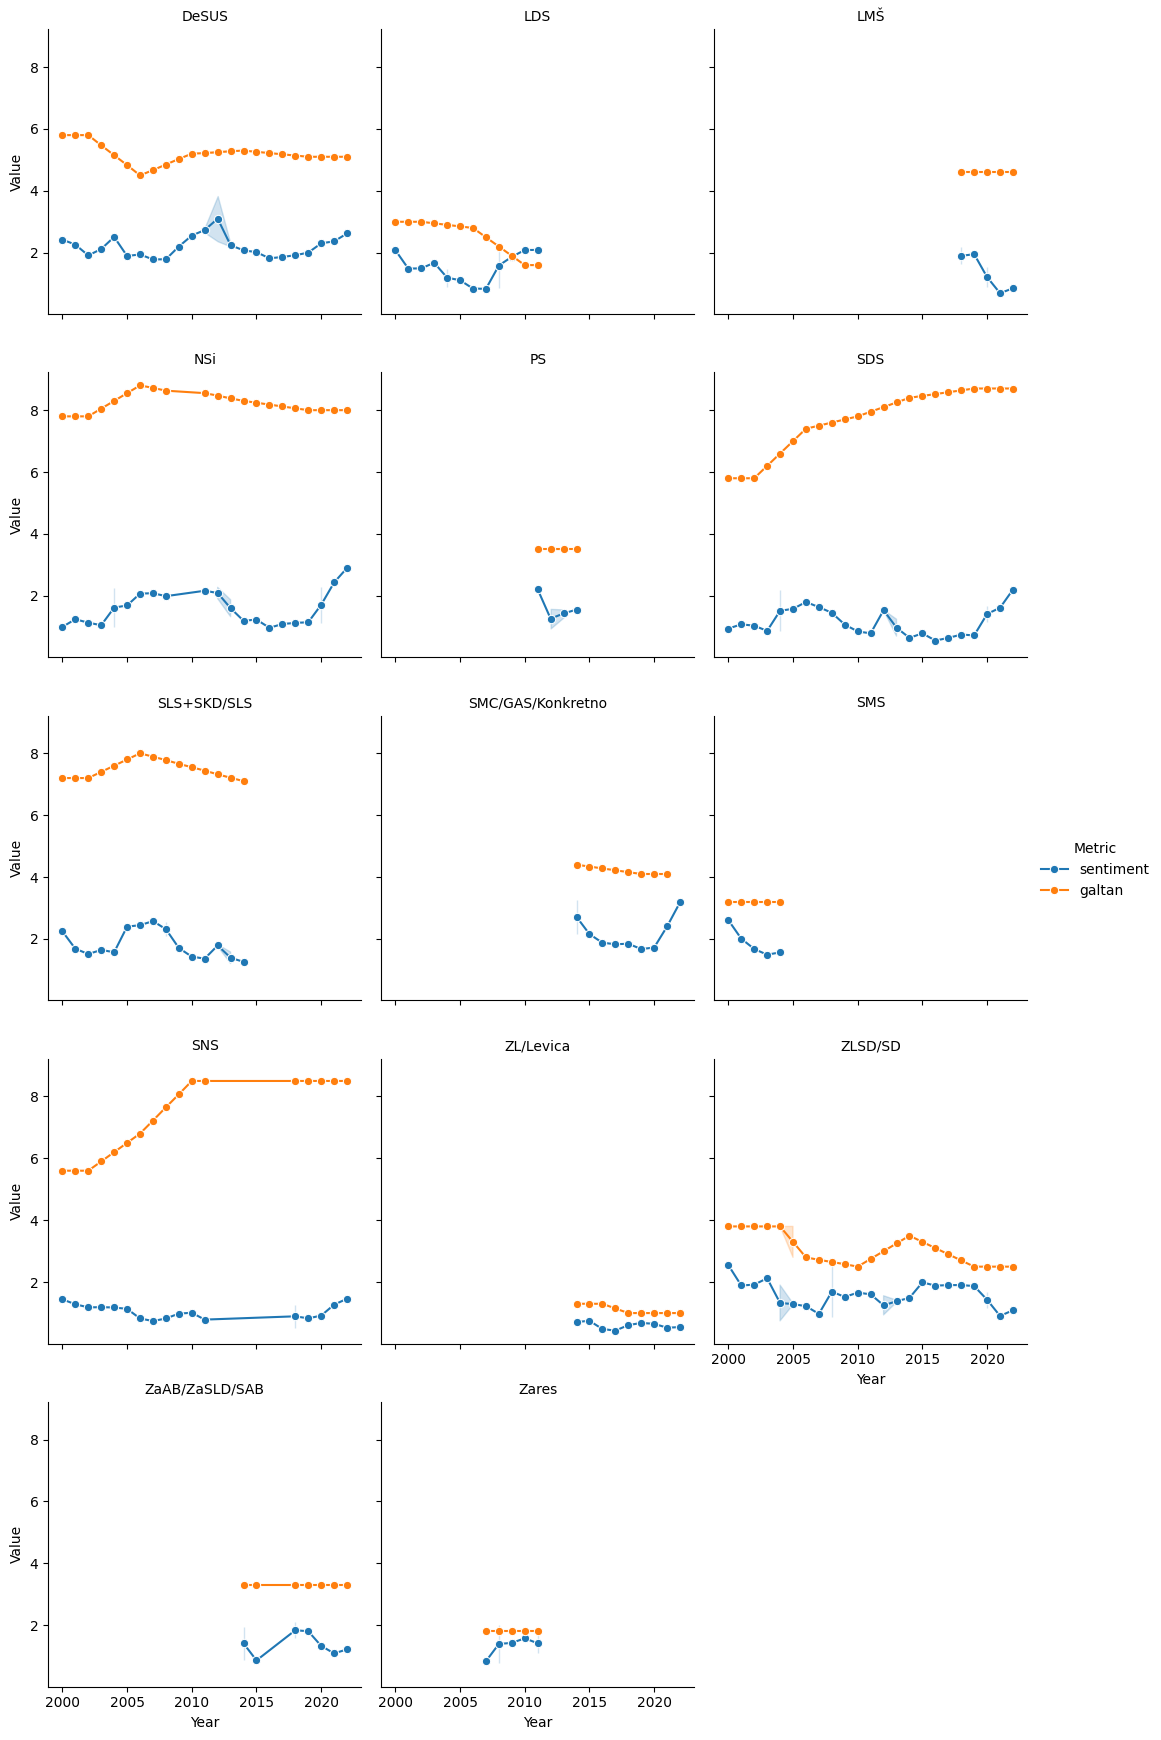

In [39]:
g = sns.FacetGrid(sent_galtan, col="Parties", col_wrap=3, height=3.5, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="Year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout
plt.show()

Relationship between sentiment and GALTAN:
The plot visualises relationship between averaged sentiment and GALTAN scores per Year per Party. The lines (or triangles) in sentiment trends denote changes in the party status (e.g. moving from opposition to coalition, or vice versa).
The same relationship, which was observed for LRGEN holds true also for GALTAN/sentiment trends, where (with exception of ZL/Levica), the trends are distinctly different in lrgen/sentiment scores. In addition to Levica, LDS does have some more distinct sentiment trends, where the sentiment rises when their galtan score lowers.